# Fase 4: Análisis Visual y Top de Riesgos de Accidentes
**Objetivo:** Simular todas las combinaciones posibles de tiempo y espacio en Cuenca, utilizar la Red Neuronal Artificial para calcular la probabilidad de riesgo ALTO y generar visualizaciones estadísticas de los resultados.

In [2]:
import pandas as pd
import numpy as np
import pickle
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model

# Configurar el estilo de los gráficos para que se vean modernos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# 1. Cargar el cerebro de la IA y los diccionarios
print("Cargando modelo y artefactos...")
modelo = load_model('modelo_alerta_cuenca_RNA.keras')

with open('encoders_fase2.pkl', 'rb') as f:
    label_encoders = pickle.load(f)
with open('scaler_fase2.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 2. Generar todas las combinaciones posibles
parroquias = label_encoders['PARROQUIA'].classes_
zonas = label_encoders['ZONA'].classes_
meses = range(1, 13)      
dias = range(7)           
horas = range(24)         

print("Generando simulaciones...")
combinaciones = list(itertools.product(parroquias, zonas, meses, dias, horas))
df_total = pd.DataFrame(combinaciones, columns=['PARROQUIA', 'ZONA', 'MES', 'DIA_SEMANA', 'HORA_NUM'])

# 3. Traducir y escalar los datos
df_procesado = df_total.copy()
df_procesado['PARROQUIA'] = label_encoders['PARROQUIA'].transform(df_procesado['PARROQUIA'])
df_procesado['ZONA'] = label_encoders['ZONA'].transform(df_procesado['ZONA'])
X_scaled = scaler.transform(df_procesado)

# 4. Realizar las predicciones masivas
print("Ejecutando inferencia en la Red Neuronal...")
predicciones = modelo.predict(X_scaled, verbose=0)

# Extraer probabilidad de ALTO y el resultado final
indice_alto = np.where(label_encoders['NIVEL_RIESGO'].classes_ == 'ALTO')[0][0]
df_total['PROB_ALTO'] = predicciones[:, indice_alto] * 100
clases_ganadoras = np.argmax(predicciones, axis=1)
df_total['RESULTADO_FINAL'] = label_encoders['NIVEL_RIESGO'].inverse_transform(clases_ganadoras)

# Mapear los nombres de los días para los gráficos
dias_nombres = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes', 5:'Sábado', 6:'Domingo'}
df_total['DIA_NOMBRE'] = df_total['DIA_SEMANA'].map(dias_nombres)

print(f"¡Análisis completado para {len(df_total)} escenarios!")

Cargando modelo y artefactos...
Generando simulaciones...
Ejecutando inferencia en la Red Neuronal...
¡Análisis completado para 88704 escenarios!


C:\Users\wwwda\AppData\Local\Temp\ipykernel_9648\1475644190.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='PROB_ALTO', y='ESCENARIO', data=top_10, palette='Reds_r')


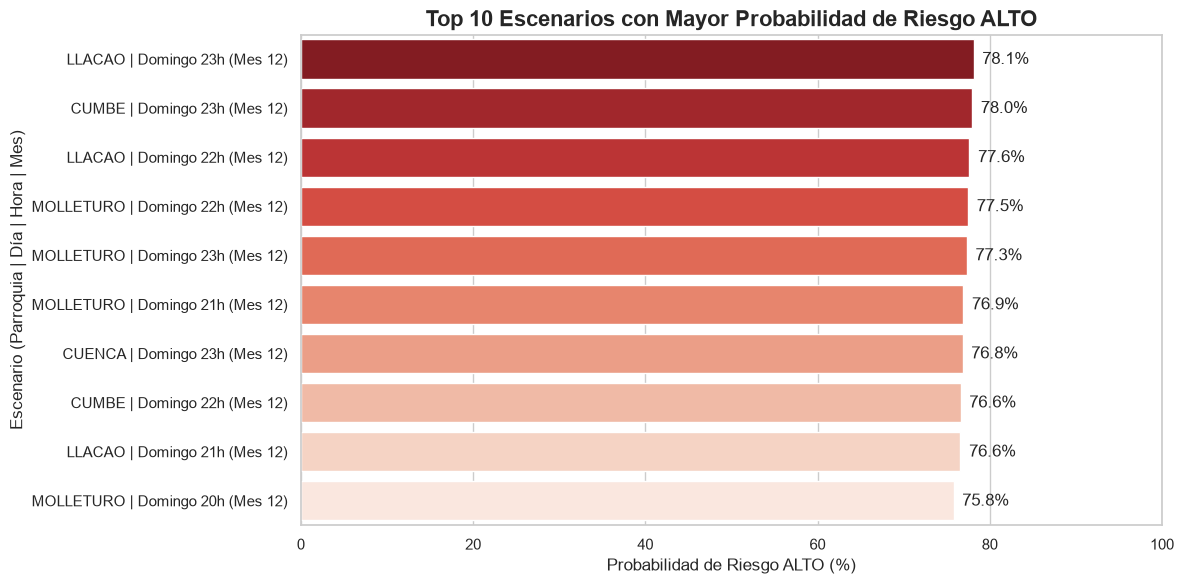

In [4]:
# Ordenar y sacar el Top 10
top_10 = df_total.sort_values(by='PROB_ALTO', ascending=False).head(10).copy()

# Crear una etiqueta combinada para el eje Y (ej: "CUENCA - Viernes 18h (Mes 10)")
top_10['ESCENARIO'] = top_10['PARROQUIA'] + " | " + top_10['DIA_NOMBRE'] + " " + top_10['HORA_NUM'].astype(str) + "h (Mes " + top_10['MES'].astype(str) + ")"

# Graficar
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='PROB_ALTO', y='ESCENARIO', data=top_10, palette='Reds_r')

plt.title('Top 10 Escenarios con Mayor Probabilidad de Riesgo ALTO', fontsize=16, fontweight='bold')
plt.xlabel('Probabilidad de Riesgo ALTO (%)', fontsize=12)
plt.ylabel('Escenario (Parroquia | Día | Hora | Mes)', fontsize=12)
plt.xlim(0, 100)

# Añadir los porcentajes al final de cada barra
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 1, p.get_y() + p.get_height()/2. + 0.1, f'{width:.1f}%', ha="left")

plt.tight_layout()
plt.show()

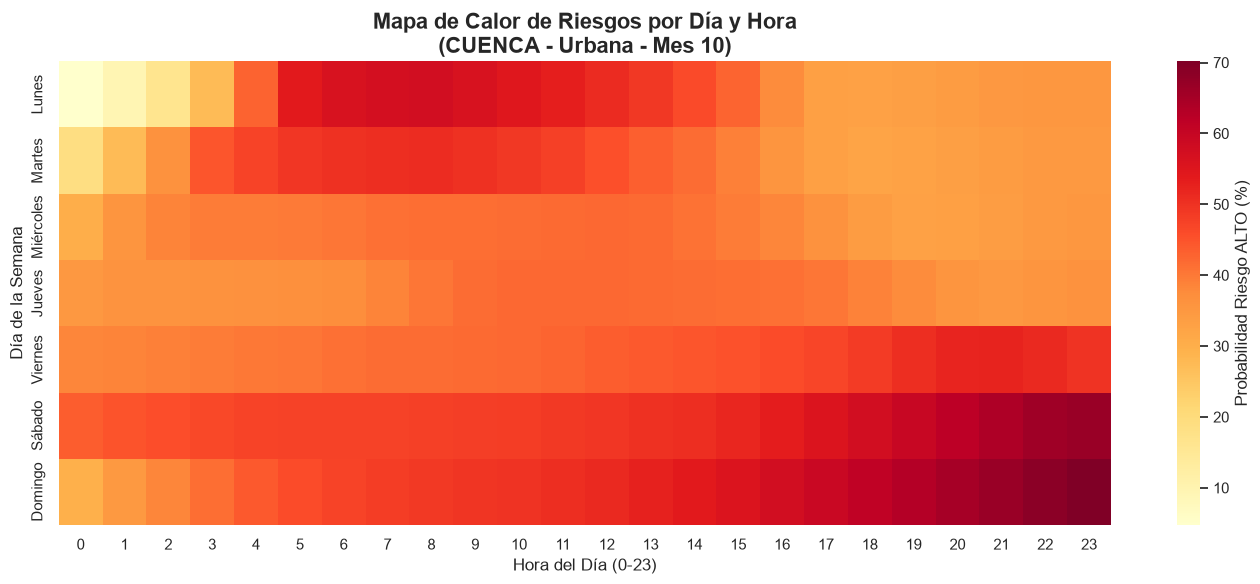

In [5]:
# Filtramos el dataset para analizar solo el área más crítica (ejemplo: CUENCA - URBANA en el mes con más riesgo)
# Puedes cambiar la parroquia y el mes según lo que notes en el Top 10
parroquia_filtro = 'CUENCA'
mes_filtro = 10 

df_heatmap = df_total[(df_total['PARROQUIA'] == parroquia_filtro) & 
                      (df_total['ZONA'] == 'URBANA') & 
                      (df_total['MES'] == mes_filtro)]

# Crear una tabla pivote (Días vs Horas) con el promedio de la probabilidad de riesgo ALTO
pivot_riesgo = df_heatmap.pivot_table(values='PROB_ALTO', index='DIA_SEMANA', columns='HORA_NUM', aggfunc='mean')
pivot_riesgo.index = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# Graficar el Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_riesgo, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Probabilidad Riesgo ALTO (%)'})

plt.title(f'Mapa de Calor de Riesgos por Día y Hora\n({parroquia_filtro} - Urbana - Mes {mes_filtro})', fontsize=16, fontweight='bold')
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)

plt.tight_layout()
plt.show()

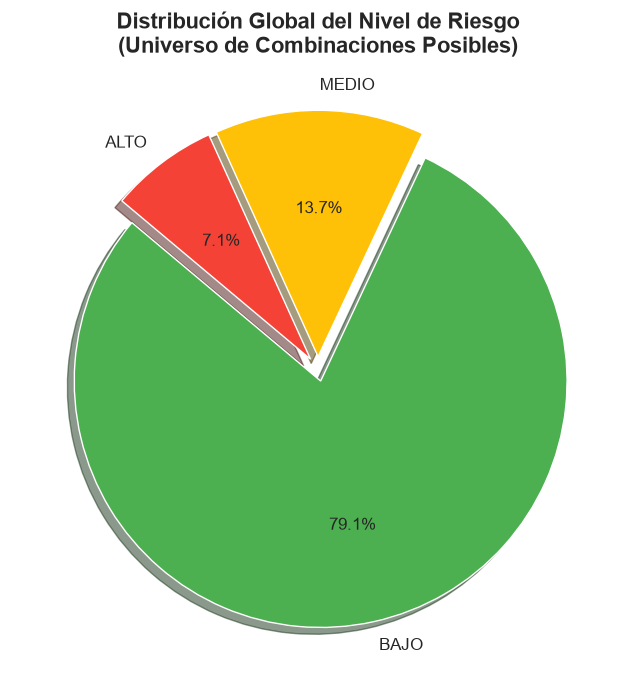

In [6]:
# Contar la cantidad de escenarios predichos en cada categoría
distribucion = df_total['RESULTADO_FINAL'].value_counts()

# Colores para Bajo, Medio y Alto
colores = ['#4CAF50', '#FFC107', '#F44336']
# Asegurarnos de que los colores coincidan con el orden de las etiquetas
etiquetas = distribucion.index
colores_mapeados = [{'BAJO': '#4CAF50', 'MEDIO': '#FFC107', 'ALTO': '#F44336'}[label] for label in etiquetas]

# Graficar
plt.figure(figsize=(8, 8))
plt.pie(distribucion, labels=etiquetas, colors=colores_mapeados, autopct='%1.1f%%', 
        startangle=140, explode=[0.05]*len(distribucion), shadow=True, textprops={'fontsize': 12})

plt.title('Distribución Global del Nivel de Riesgo\n(Universo de Combinaciones Posibles)', fontsize=16, fontweight='bold')
plt.show()